# Can you trade maple syrup? 🍁
### Quebec runs a *strategic maple-syrup reserve* — so is there a maple trade, or just a great story?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_a_curio%3F: Confirmed](https://img.shields.io/badge/Just_a_curio%3F-Confirmed-8b949e?style=flat-square)

It sounds made up, but it's real: the Canadian province of Quebec — which makes about **72% of the world's maple syrup** — runs a **Global Strategic Maple Syrup Reserve**, a warehouse full of barrels that a producers' cartel uses to prop up the price, exactly the way a central bank hoards gold or OPEC hoards oil. In **2011-2012** thieves siphoned **~C$18.7M** of syrup out of it — the "Great Canadian Maple Syrup Heist." A strategic reserve, a cartel, a heist... surely there's a *trade* in here somewhere?

This notebook goes looking. Is the maple price something a holder gets paid to own? Is there anything you can actually **buy**? And since sap runs on a late-winter schedule, is there a **sugaring-season seasonal**? Spoiler in the badges above — but the *why* is the fun part.

> 📓 **Plain-language layer.** Want the *t*-stats, the Newey-West alpha and the block-bootstrap? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice — and a data note.** There is **no** maple exchange or maple futures; the world price is *administered* by the Quebec cartel. So the price line below is a **small, clearly-cited, approximate** reconstruction of the negotiated bulk price — a **proxy**, never a live feed. The one buyable name is **Rogers Sugar** (`RSI.TO`), a sugar refiner that also bottles maple — a *labelled proxy*, not a barrel of syrup. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # the repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, SYRUP = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#d1651a"

from maple_syrup_reserve import data, strategy as st
try:
    from quantlab import repro
    ASOF = repro.DEFAULT_AS_OF
except Exception:
    repro = None; ASOF = "2026-06-01"

HAVE_PROXIES = data.have_proxies()
MAPLE = data.load_maple_price()                      # hardcoded, cited, APPROXIMATE proxy
if HAVE_PROXIES:
    PROX = data.load_proxies()
    if repro is not None:
        PROX = {t: repro.as_of(s.to_frame("x")).iloc[:, 0] for t, s in PROX.items()}
else:
    PROX = None
print("equity-proxy cache present:", HAVE_PROXIES,
      "| maple-price years:", MAPLE.index[0].year, "->", MAPLE.index[-1].year, "| as-of", ASOF)

# frozen headline numbers (mirror of docs/results.md)
R = {'maple_win': '2008 → 2024', 'maple_levels': {2008: 2.6, 2009: 2.65, 2010: 2.72, 2011: 2.85, 2012: 2.92, 2013: 2.94, 2014: 2.9, 2015: 2.86, 2016: 2.85, 2017: 2.88, 2018: 2.85, 2019: 2.84, 2020: 2.85, 2021: 2.86, 2022: 3.02, 2023: 3.35, 2024: 3.6}, 'maple_cagr': 2.05, 'maple_vol': 3.5, 'maple_sharpe': 0.61, 'maple_mdd': -3.4, 'tsx_cagr_ye': 4.45, 'tsx_vol_ye': 11.9, 'tsx_mdd_ye': -11.6, 'excess_mean': -3.0, 'excess_t': -0.906, 'excess_p': 0.381, 'excess_n': 14, 'rsi_cagr': 9.39, 'rsi_vol': 15.7, 'rsi_sharpe': 0.65, 'rsi_mdd': -24.4, 'rsi_alpha': 6.56, 'rsi_beta': 0.5, 'rsi_t': 1.83, 'rsi_p': 0.069, 'rsi_n': 196, 'sb_cagr': -4.52, 'sb_vol': 33.4, 'sb_sharpe': 0.0, 'sb_mdd': -69.4, 'sb_alpha': 1.71, 'sb_beta': -0.21, 'sb_t': 0.19, 'sb_p': 0.848, 'sb_n': 167, 'tsx_cagr': 7.25, 'tsx_vol': 11.9, 'tsx_sharpe': 0.65, 'tsx_mdd': -22.7, 'month_mean': {1: -0.02, 2: 1.46, 3: 1.8, 4: 0.58, 5: 0.23, 6: 0.87, 7: 2.16, 8: -0.52, 9: 1.17, 10: -1.54, 11: 2.46, 12: 1.52}, 'month_thac': {1: -0.02, 2: 1.76, 3: 2.58, 4: 1.0, 5: 0.19, 6: 1.6, 7: 5.12, 8: -0.52, 9: 1.88, 10: -1.64, 11: 1.97, 12: 2.09}, 'season_mean': 1.28, 'rest_mean': 0.7, 'season_spread': 0.58, 'season_t': 0.81, 'n_season': 51, 'n_rest': 145, 'ci_lo': -0.71, 'ci_hi': 1.95, 'ci_point': 0.58, 'mar_thac': 2.58, 'jul_thac': 5.12, 'feb_thac': 1.76, 'timer_gross_cagr': 9.11, 'timer_net_cagr': 8.78, 'bh_rsi_cagr': 9.38, 'bh_tsx_cagr': 7.24, 'timer_gross_sharpe': 0.22, 'timer_net_sharpe': 0.18, 'bh_rsi_sharpe': 0.16, 'world_share': 72, 'reserve_mlb': 100, 'heist_year': '2011-2012', 'heist_cad_m': 18.7, 'heist_tonnes': 3000, 'syn_planted': 6.0, 'syn_spread': 3.3, 'syn_t': 3.77, 'syn_sign_ok': 1, 'fp_proxies': '2f0f50f97e59', 'fp_maple': '123be1d12a41', 'as_of': '2026-06-01'}


equity-proxy cache present: True | maple-price years: 2008 -> 2024 | as-of 2026-06-01


## The answer first

| Question | Answer |
|---|---|
| Is the reserve real? | **Completely.** A cartel (the PPAQ) stockpiles millions of pounds of syrup to defend the price; the 2011-2012 heist really happened. |
| Does the maple price reward a holder? | **Barely.** The administered bulk price crept **~2%/yr** over 2008–2024 — *below* the S&P/TSX's **~4%/yr**, with almost no movement at all. It's a set price, not a market. |
| Can you actually buy the trade? | **Not really.** No maple futures exist. The only listed name is **Rogers Sugar** — a *sugar* company that happens to bottle maple. It did fine (**9%/yr**) but that's a defensive dividend stock, **not the maple price**. |
| Is there a sugaring-season seasonal? | **No.** Feb–Apr beat the rest of the year by only **0.58%/mo** (*t* = 0.81); the confidence band runs from **-0.7%** to **+1.9%** — straight through zero. |

> The reserve is a wonderful story. The *trade* is a mirage: a set price you can't buy, a proxy that's really just a sugar stock, and a season that's noise. **A curio, confirmed.**

## 1 · The claim

> *"Maple syrup is a strategic commodity. Quebec runs a reserve to control its price like OPEC controls oil — so maple is a real, ownable soft commodity, with a natural sugaring-season rhythm you could trade."*

It is a *steelman-able* claim, because every ingredient is true. Quebec produces the large majority of the world's syrup (~72%). Its cartel — **Producteurs et productrices acéricoles du Québec** — really does run a **strategic reserve** of up to ~100 million pounds and really does negotiate the bulk price. And the **2011-2012 heist** (≈ C$18.7M, ~3,000 tonnes) proved the barrels are worth stealing. If *that* isn't a commodity market, what is?

## 2 · So what?

If maple were a genuine tradable commodity, it would be a lovely little uncorrelated corner of a portfolio — a real-asset store of value with a weather-driven seasonal, the kind of thing a macro fund would love. But "there is a cartel and a reserve" and "there is a *trade*" are very different statements. A managed price can be rock-steady precisely *because* it's managed — which is the opposite of an opportunity. And a reserve exists to **remove** volatility, not to create the swings a trader needs. We can check whether any of the three tradable stories — hold it, buy a proxy, time the season — actually pays.

## 3 · How would we even know?

Three honest checks, each against the S&P/TSX Composite (the CAD-home benchmark, since the one buyable name is Canadian):

1. **Does holding maple pay?** Put the (cited, approximate) administered bulk price next to the TSX on the same clock — return, volatility, drawdown.
2. **Can you buy it?** You can't buy "maple." You *can* buy **Rogers Sugar** (`RSI.TO`), the one listed firm with a maple-bottling arm. Does it hand you a *maple* return — or just a sugar-stock return? (We also check `SB=F`, sugar futures — the nearest sweetener, a pure placebo.)
3. **Is there a season?** Sap runs Feb–Apr. Do those months pay more, and could you time them net of cost?

**What would make us say "a real maple trade"?** A robust signal (*t* ≥ 2) that maple beats stocks, *or* real alpha in the proxy, *or* a significant sugaring-season edge. Anything less is a curio.

## 4 · The teardown — let's actually look

**First: what does an *administered* price look like?** Here is the (approximate, cited) PPAQ bulk price of maple syrup — the number the cartel negotiates each year.

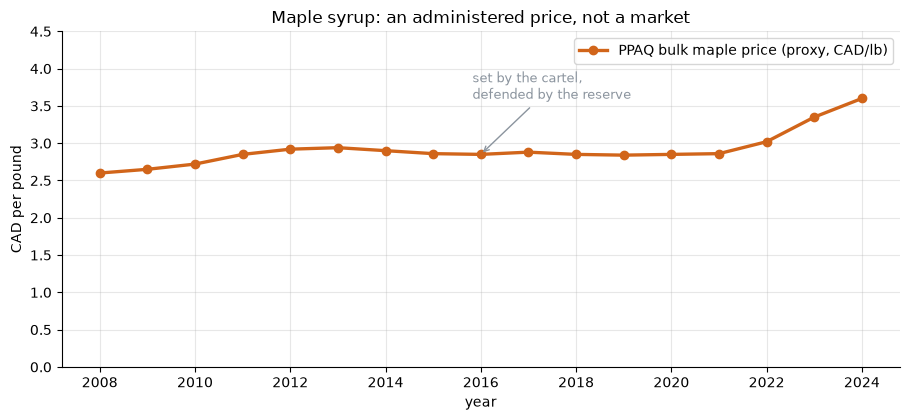

maple CAGR ~2.0%/yr,  annual vol ~3.5% (a real commodity swings 25-40%/yr)


In [2]:
yrs = list(R['maple_levels'].keys())
lv = [float(MAPLE.loc[f'{y}-12-31']) for y in yrs] if HAVE_PROXIES or True else list(R['maple_levels'].values())
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(yrs, lv, 'o-', c=SYRUP, lw=2.4, label='PPAQ bulk maple price (proxy, CAD/lb)')
ax.set_xlabel('year'); ax.set_ylabel('CAD per pound')
ax.set_ylim(0, max(lv)*1.25)
ax.annotate('set by the cartel,\ndefended by the reserve', (2016, lv[8]),
            textcoords='offset points', xytext=(-6, 40), color=GREY, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=GREY))
ax.set_title('Maple syrup: an administered price, not a market'); ax.legend()
plt.tight_layout(); plt.show()
print(f"maple CAGR ~{R['maple_cagr']:.1f}%/yr,  annual vol ~{R['maple_vol']:.1f}% "
      f"(a real commodity swings 25-40%/yr)")

That flat, orderly creep — **~2%/yr** with **~4%** annual volatility — is the whole story. A freely-traded soft commodity (coffee, sugar, cocoa) swings 25–40% a year. Maple barely moves because a committee *sets* it and a warehouse full of barrels defends it. Steady is nice for a producer; for a trader it means **there is nothing to trade**.

**Now the race: did holding maple beat stocks?** Same years, rebased to 100.

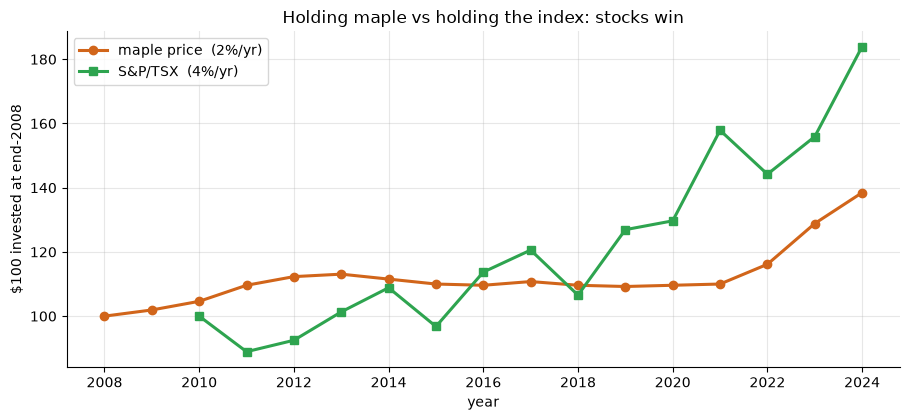

maple ~2.0%/yr  vs  TSX ~4.5%/yr  |  annual excess -3.0%/yr (t=-0.91, n=14)


In [3]:
if HAVE_PROXIES:
    tsx_ye = PROX['^GSPTSE'].resample('YE').last()
    tsx_ye = tsx_ye[(tsx_ye.index.year>=2008)&(tsx_ye.index.year<=2024)]
    tx = [d.year for d in tsx_ye.index]; ty = list((tsx_ye/tsx_ye.iloc[0]*100).values)
else:
    tx = yrs; ty = [100*(1+R['tsx_cagr_ye']/100)**(y-2008) for y in yrs]
mn = [100*v/lv[0] for v in lv]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(yrs, mn, 'o-', c=SYRUP, lw=2.2, label=f"maple price  ({R['maple_cagr']:.0f}%/yr)")
ax.plot(tx, ty, 's-', c=GREEN, lw=2.2, label=f"S&P/TSX  ({R['tsx_cagr_ye']:.0f}%/yr)")
ax.set_xlabel('year'); ax.set_ylabel('$100 invested at end-2008')
ax.set_title('Holding maple vs holding the index: stocks win'); ax.legend()
plt.tight_layout(); plt.show()
print(f"maple ~{R['maple_cagr']:.1f}%/yr  vs  TSX ~{R['tsx_cagr_ye']:.1f}%/yr  |  "
      f"annual excess {R['excess_mean']:+.1f}%/yr (t={R['excess_t']:+.2f}, n={R['excess_n']})")

The index roughly **doubled** the maple price's growth (**~4%** vs **~2%/yr**). The administered price didn't just fail to beat stocks — it trailed them, while being *designed* not to move. A store of value that grows at 2% a year is a savings account, not a trade.

**"Fine — I'll buy the maple *company*."** You essentially can't: there's one listed name with real maple exposure, **Rogers Sugar** (`RSI.TO`), and it's mostly a *sugar* refiner. Here's how it, sugar futures, and the index stack up.

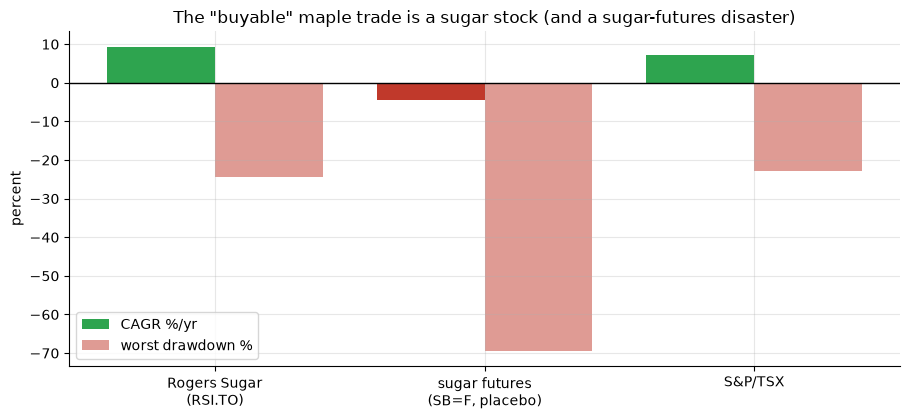

RSI.TO CAGR 9.4% (a defensive sugar refiner, beta 0.50)
SB=F   CAGR -4.5% — the nearest tradable sweetener, nothing to do with maple


In [4]:
if HAVE_PROXIES:
    rows = {}
    for t in ['RSI.TO','SB=F','^GSPTSE']:
        s = st.summarize(PROX[t]); rows[t] = (s['cagr']*100, s['mdd']*100)
else:
    rows = {'RSI.TO':(R['rsi_cagr'],R['rsi_mdd']),'SB=F':(R['sb_cagr'],R['sb_mdd']),'^GSPTSE':(R['tsx_cagr'],R['tsx_mdd'])}
names = ['Rogers Sugar\n(RSI.TO)', 'sugar futures\n(SB=F, placebo)', 'S&P/TSX']
cagrs = [rows['RSI.TO'][0], rows['SB=F'][0], rows['^GSPTSE'][0]]
mdds  = [rows['RSI.TO'][1], rows['SB=F'][1], rows['^GSPTSE'][1]]
x = np.arange(3); fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, cagrs, .4, color=[GREEN if c>0 else RED for c in cagrs], label='CAGR %/yr')
ax.bar(x+.2, mdds, .4, color=RED, alpha=.5, label='worst drawdown %')
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('percent'); ax.set_title('The "buyable" maple trade is a sugar stock (and a sugar-futures disaster)'); ax.legend()
plt.tight_layout(); plt.show()
print(f"RSI.TO CAGR {rows['RSI.TO'][0]:.1f}% (a defensive sugar refiner, beta {R['rsi_beta']:.2f})")
print(f"SB=F   CAGR {rows['SB=F'][0]:.1f}% — the nearest tradable sweetener, nothing to do with maple")

Rogers Sugar did fine (**9%/yr**) — but as a low-beta, dividend-paying *sugar* refiner, not because of maple: its price and the maple bulk price barely relate. And the one actual traded sweetener, sugar futures, **lost 5%/yr** with a **-69%** drawdown. Neither is a maple trade; one is a decent dividend stock, the other is a wood-chipper for money.

**Last: the sugaring season.** Sap runs Feb–Apr. If there's a maple rhythm, those months should light up. Here are Rogers Sugar's average monthly returns, sugaring months in maple-orange.

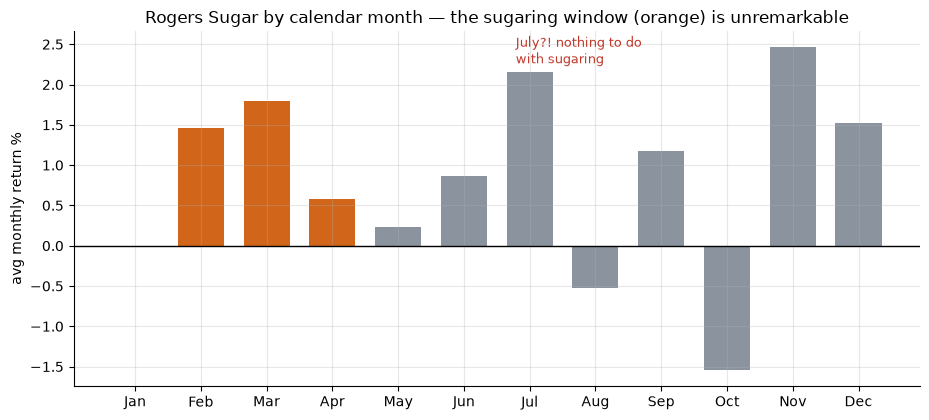

Feb-Apr avg 1.28%/mo vs rest 0.70%/mo  -> spread +0.58%/mo (t=0.81)


In [5]:
mm = [R['month_mean'][m] for m in range(1,13)]
abbr = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cols = [SYRUP if m in (2,3,4) else GREY for m in range(1,13)]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(abbr, mm, color=cols, width=.7)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg monthly return %')
ax.annotate('July?! nothing to do\nwith sugaring', (6, mm[6]), textcoords='offset points',
            xytext=(-10, 6), color=RED, fontsize=9)
ax.set_title('Rogers Sugar by calendar month — the sugaring window (orange) is unremarkable')
plt.tight_layout(); plt.show()
print(f"Feb-Apr avg {R['season_mean']:.2f}%/mo vs rest {R['rest_mean']:.2f}%/mo  "
      f"-> spread {R['season_spread']:+.2f}%/mo (t={R['season_t']:.2f})")

The sugaring months (orange) are fine but forgettable: Feb–Apr averaged **1.28%/mo** vs **0.70%/mo** for the rest — a **+0.58%/mo** gap that's easily noise (*t* = 0.81). The biggest month is **July** — which has *nothing* to do with sugaring. When your strongest "seasonal" is a month with no story, you're looking at randomness, not a rhythm.

## 5 · The verdict

- **Signal — None.** The administered price grew ~2%/yr (below stocks, and by design barely moving); the only buyable proxy is a sugar stock with no maple link; the sugaring season is statistically flat. Nothing here beats noise in maple's favour.
- **Tradability — Mirage.** There is no maple market to trade — no exchange, no futures, a committee-set price. The 'trade' collapses to owning a dividend sugar stock, and timing its 'season' loses to just holding it.
- **Just a curio? — Confirmed.** A brilliant story (cartel, reserve, heist) with no edge attached. Enjoy it on the pancakes.

## 6 · Could you actually trade it? — the honest bottom line

Suppose you're determined to "trade maple" at the end of 2009 with \$10,000. You can't buy syrup, so you buy the closest thing — Rogers Sugar — and you cleverly *time the sugaring season*. Does the cleverness pay, versus just holding the stock, or the index?

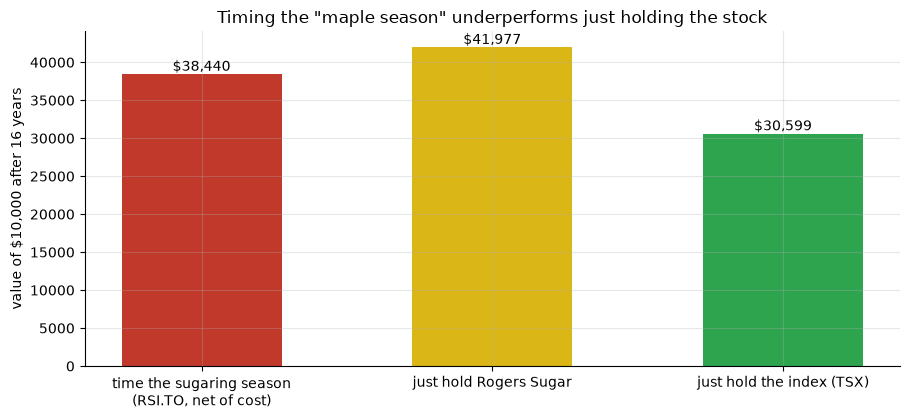

time the sugaring season           $    38,440  (+8.8%/yr)
just hold Rogers Sugar             $    41,977  (+9.4%/yr)
just hold the index (TSX)          $    30,599  (+7.2%/yr)


In [6]:
start = 10_000.0; yrs_h = 16
paths = {'time the sugaring season\n(RSI.TO, net of cost)': R['timer_net_cagr']/100,
         'just hold Rogers Sugar': R['bh_rsi_cagr']/100,
         'just hold the index (TSX)': R['bh_tsx_cagr']/100}
labels=list(paths); ends=[start*(1+g)**yrs_h for g in paths.values()]
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(labels, ends, .55, color=[RED, AMBER, GREEN])
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('value of $10,000 after 16 years')
ax.set_title('Timing the "maple season" underperforms just holding the stock')
plt.tight_layout(); plt.show()
for l,g in paths.items(): print(f"{l.split(chr(10))[0]:34s} ${start*(1+g)**yrs_h:>10,.0f}  ({g*100:+.1f}%/yr)")

The clever seasonal timer ends up **behind** the do-nothing 'just hold the stock' — the season it's timing isn't there, so all it does is add trading costs and step out of good months. And remember: none of this is *maple*. It's a sugar stock. The maple part of the story bought you exactly nothing. The people who 'made money in maple' are the cartel and the thieves — not investors.

## 7 · Going further 🚪

- **Pull the real PPAQ series.** Our price line is a cited *approximation* of the negotiated bulk price; the PPAQ publishes the actual conventions. Swap it in — the *flatness* (and the verdict) won't move.
- **The administered-commodity pattern.** Anything with a marketing board or a strategic reserve — orange juice, rare-earths, even the US oil reserve — tends to be *managed* toward calm, which is the opposite of a trade (see [docs/references.md](../docs/references.md)).
- **The other soft-commodity curios.** Compare with [Study 307 — Coffee-Seasonality](../../307-coffee-seasonality/) and [Study 358 — Watch-Index](../../358-watch-index/): a real futures market with a real (tiny) seasonal, and a collectible with no tradable index — maple sits below both.

*Think a specific maple-linked name or a tighter sugaring window hides an edge? Pull it, charge the spread, and show it — then check your best 'season' isn't just July in disguise.*